# Proyecto - Predicción de Importaciones para Cencosud

Este notebook implementa un flujo de trabajo reproducible para estimar las importaciones de electrodomésticos en Chile con foco en apoyar la planificación logística y de abastecimiento de **Cencosud**.

## Objetivo
Construir un modelo predictivo que permita estimar el comportamiento futuro de las importaciones de electrodomésticos en Chile.

## Variables analizadas
- `valor_cif`
- `peso`
- `cantidad`

## Códigos HS considerados
- `8418`: Refrigeradores
- `8450`: Lavadoras
- `8516`: Microondas / hornos eléctricos
- `8528`: Televisores

## Horizonte de predicción
- `6 meses`

## Modelos a comparar
- ARIMA
- Regresión Lineal
- Random Forest
- XGBoost
- LightGBM

> **Nota importante**: Este notebook fue corregido para trabajar de forma coherente con columnas en **minúscula** y con los archivos:
> - `importaciones_hs_filtrado_estandarizado.csv`
> - `importaciones_hs_filtrado_raw.csv`

## BLOQUE 2 — Librerías a utilizar

In [1]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import os
import re
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

from statsmodels.tsa.arima.model import ARIMA

# Modelos opcionales
xgboost_disponible = True
lightgbm_disponible = True

try:
    from xgboost import XGBRegressor
except Exception:
    xgboost_disponible = False

try:
    from lightgbm import LGBMRegressor
except Exception:
    lightgbm_disponible = False

print("Librerías cargadas correctamente.")
print(f"XGBoost disponible: {xgboost_disponible}")
print(f"LightGBM disponible: {lightgbm_disponible}")

Librerías cargadas correctamente.
XGBoost disponible: True
LightGBM disponible: True


## BLOQUE 3 — Parámetros del proyecto

In [2]:
# Rutas
REPO_DIR = "/content/MBD00010"
RAW_DATA_DIR = "/content/drive/MyDrive/Mod10/proyecto_cencosud_importaciones/data/raw/aduanas"
PROCESSED_DIR = "/content/drive/MyDrive/Mod10/proyecto_cencosud_importaciones/data/processed"

BASE_DIR = Path(r"C:\Users\roberto.sepulveda\OneDrive - udp.cl\Escritorio\Roberto\Magister 2025\MBD0010\Tarea_Final\Proyecto_Logistica_Cencosud")
DATA_DIR = BASE_DIR / "data" / "processed"
RESULTS_DIR = BASE_DIR / "results"
GRAPHICS_DIR = RESULTS_DIR / "graphics"
TABLES_DIR = RESULTS_DIR / "tables"

RESULTS_DIR.mkdir(parents=True, exist_ok=True)
GRAPHICS_DIR.mkdir(parents=True, exist_ok=True)
TABLES_DIR.mkdir(parents=True, exist_ok=True)

# Archivos
FILE_EST = DATA_DIR / "importaciones_hs_filtrado_estandarizado.csv"
FILE_RAW = DATA_DIR / "importaciones_hs_filtrado_raw.csv"

# Parámetros analíticos
HS_CODES_OBJETIVO = ["8418", "8450", "8516", "8528"]
VARIABLES_OBJETIVO = ["valor_cif", "peso", "cantidad"]
HORIZONTE_MESES = 6

print("Rutas configuradas correctamente.")
print("Archivo estandarizado:", FILE_EST)
print("Archivo raw:", FILE_RAW)

Rutas configuradas correctamente.
Archivo estandarizado: C:\Users\roberto.sepulveda\OneDrive - udp.cl\Escritorio\Roberto\Magister 2025\MBD0010\Tarea_Final\Proyecto_Logistica_Cencosud\data\processed\importaciones_hs_filtrado_estandarizado.csv
Archivo raw: C:\Users\roberto.sepulveda\OneDrive - udp.cl\Escritorio\Roberto\Magister 2025\MBD0010\Tarea_Final\Proyecto_Logistica_Cencosud\data\processed\importaciones_hs_filtrado_raw.csv


## BLOQUE 4 — Funciones auxiliares

In [3]:
def leer_csv_seguro(path_obj):
    """
    Intenta leer un CSV con varias combinaciones comunes de encoding y separador.
    """
    intentos = [
        {"sep": ",", "encoding": "utf-8"},
        {"sep": ";", "encoding": "utf-8"},
        {"sep": ",", "encoding": "latin-1"},
        {"sep": ";", "encoding": "latin-1"},
    ]
    
    for intento in intentos:
        try:
            df_tmp = pd.read_csv(path_obj, sep=intento["sep"], encoding=intento["encoding"], low_memory=False)
            if df_tmp.shape[1] > 1:
                print(f"[OK] Lectura exitosa: {path_obj.name} | sep='{intento['sep']}' | encoding='{intento['encoding']}'")
                return df_tmp
        except Exception:
            continue
    
    raise ValueError(f"No fue posible leer el archivo: {path_obj}")


def estandarizar_columnas(df):
    df = df.copy()
    df.columns = [str(c).strip().lower() for c in df.columns]
    return df


def detectar_columna_fecha(df):
    candidatos = ["fectra", "fecha", "fecha_documento", "fecha_registro", "fec_tra", "fechadoc"]
    for c in candidatos:
        if c in df.columns:
            return c
    return None


def detectar_columna_codigo_arancel(df):
    candidatos = ["codigo_arancel", "aranc_nac", "codigo_hs", "partida", "hs", "codigo"]
    for c in candidatos:
        if c in df.columns:
            return c
    return None


def parsear_fecha_robusta(serie):
    """
    Intenta convertir fechas con diferentes formatos.
    """
    s = serie.copy()

    # intento general
    f1 = pd.to_datetime(s, errors="coerce", dayfirst=True)
    if f1.notna().sum() > 0:
        return f1

    # intento con solo dígitos YYYYMMDD
    s2 = s.astype(str).str.replace(r"[^0-9]", "", regex=True)
    f2 = pd.to_datetime(s2, format="%Y%m%d", errors="coerce")
    if f2.notna().sum() > 0:
        return f2

    # intento alternativo YYYY-MM-DD implícito
    f3 = pd.to_datetime(s.astype(str), errors="coerce")
    return f3


def reconstruir_hs4(df, col_hs4="hs4", col_codigo_arancel=None):
    """
    Reconstruye hs4 de forma robusta.
    Prioridad:
    1) hs4 existente
    2) codigo_arancel
    """
    df = df.copy()

    base = None

    if col_hs4 in df.columns:
        base = df[col_hs4].astype(str)

    if col_codigo_arancel and col_codigo_arancel in df.columns:
        base_alt = df[col_codigo_arancel].astype(str)

        # Si hs4 no sirve o está vacío, preferir codigo_arancel
        if base is None:
            base = base_alt
        else:
            base = np.where(
                base.astype(str).str.strip().isin(["", "nan", "none"]),
                base_alt,
                base
            )
            base = pd.Series(base, index=df.index)

    if base is None:
        df["hs4_limpio"] = np.nan
        return df

    hs4_limpio = (
        pd.Series(base, index=df.index)
        .astype(str)
        .str.strip()
        .str.replace(r"[^0-9]", "", regex=True)
        .str[:4]
    )

    df["hs4_limpio"] = hs4_limpio
    return df


def asegurar_numericas(df, cols):
    df = df.copy()
    for c in cols:
        if c in df.columns:
            df[c] = pd.to_numeric(df[c], errors="coerce").fillna(0)
        else:
            df[c] = 0
    return df


def crear_features_temporales(df, target_col):
    """
    Crea variables simples de series de tiempo para modelos supervisados.
    """
    d = df.copy().sort_values("fecha_mes").reset_index(drop=True)
    d["t"] = np.arange(len(d))
    d["mes"] = d["fecha_mes"].dt.month
    d["anio"] = d["fecha_mes"].dt.year
    d["lag_1"] = d[target_col].shift(1)
    d["lag_2"] = d[target_col].shift(2)
    d["lag_3"] = d[target_col].shift(3)
    d["rolling_3"] = d[target_col].shift(1).rolling(3).mean()
    d["rolling_6"] = d[target_col].shift(1).rolling(6).mean()
    return d


def metricas_regresion(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    try:
        mape = np.mean(np.abs((y_true - y_pred) / np.where(y_true == 0, 1, y_true))) * 100
    except Exception:
        mape = np.nan
    r2 = r2_score(y_true, y_pred) if len(y_true) > 1 else np.nan
    return {
        "mae": mae,
        "rmse": rmse,
        "mape": mape,
        "r2": r2
    }


def entrenar_y_evaluar_supervisado(df_feat, target_col, nombre_modelo, modelo):
    d = df_feat.dropna().copy()

    if len(d) < 12:
        return None, None, f"No hay suficientes datos para {nombre_modelo}"

    features = ["t", "mes", "anio", "lag_1", "lag_2", "lag_3", "rolling_3", "rolling_6"]
    X = d[features]
    y = d[target_col]

    test_size = max(6, int(len(d) * 0.2))
    if len(d) <= test_size:
        return None, None, f"Datos insuficientes para particionar en {nombre_modelo}"

    X_train, X_test = X.iloc[:-test_size], X.iloc[-test_size:]
    y_train, y_test = y.iloc[:-test_size], y.iloc[-test_size:]

    modelo.fit(X_train, y_train)
    y_pred = modelo.predict(X_test)

    mets = metricas_regresion(y_test, y_pred)
    mets["modelo"] = nombre_modelo

    pred_df = pd.DataFrame({
        "fecha_mes": d.iloc[-test_size:]["fecha_mes"].values,
        "y_real": y_test.values,
        "y_pred": y_pred
    })

    return mets, pred_df, None


def forecast_supervisado(df_feat, target_col, modelo):
    d = df_feat.copy().sort_values("fecha_mes").reset_index(drop=True)
    d_model = d.dropna().copy()

    if len(d_model) < 12:
        return None

    features = ["t", "mes", "anio", "lag_1", "lag_2", "lag_3", "rolling_3", "rolling_6"]
    X = d_model[features]
    y = d_model[target_col]
    modelo.fit(X, y)

    futuro = d.copy()
    ultima_fecha = futuro["fecha_mes"].max()

    for _ in range(HORIZONTE_MESES):
        nueva_fecha = ultima_fecha + pd.offsets.MonthBegin(1)
        nueva_fila = {
            "fecha_mes": nueva_fecha,
            target_col: np.nan
        }
        futuro = pd.concat([futuro, pd.DataFrame([nueva_fila])], ignore_index=True)

        futuro["t"] = np.arange(len(futuro))
        futuro["mes"] = futuro["fecha_mes"].dt.month
        futuro["anio"] = futuro["fecha_mes"].dt.year
        futuro["lag_1"] = futuro[target_col].shift(1)
        futuro["lag_2"] = futuro[target_col].shift(2)
        futuro["lag_3"] = futuro[target_col].shift(3)
        futuro["rolling_3"] = futuro[target_col].shift(1).rolling(3).mean()
        futuro["rolling_6"] = futuro[target_col].shift(1).rolling(6).mean()

        row_pred = futuro.iloc[[-1]][features]
        pred = modelo.predict(row_pred)[0]
        futuro.loc[futuro.index[-1], target_col] = pred

        ultima_fecha = nueva_fecha

    salida = futuro.tail(HORIZONTE_MESES)[["fecha_mes", target_col]].copy()
    salida.rename(columns={target_col: "forecast"}, inplace=True)
    return salida


def entrenar_y_evaluar_arima(df_ts, target_col):
    d = df_ts[["fecha_mes", target_col]].dropna().copy().sort_values("fecha_mes")
    if len(d) < 18:
        return None, None, "No hay suficientes datos para ARIMA"

    serie = d[target_col].astype(float).values
    test_size = max(6, int(len(d) * 0.2))

    train = serie[:-test_size]
    test = serie[-test_size:]
    fechas_test = d["fecha_mes"].iloc[-test_size:].values

    try:
        modelo = ARIMA(train, order=(1, 1, 1))
        ajuste = modelo.fit()
        pred = ajuste.forecast(steps=test_size)

        mets = metricas_regresion(test, pred)
        mets["modelo"] = "ARIMA"

        pred_df = pd.DataFrame({
            "fecha_mes": fechas_test,
            "y_real": test,
            "y_pred": pred
        })

        return mets, pred_df, None
    except Exception as e:
        return None, None, str(e)


def forecast_arima(df_ts, target_col):
    d = df_ts[["fecha_mes", target_col]].dropna().copy().sort_values("fecha_mes")
    if len(d) < 18:
        return None

    serie = d[target_col].astype(float).values

    try:
        modelo = ARIMA(serie, order=(1, 1, 1))
        ajuste = modelo.fit()
        pred = ajuste.forecast(steps=HORIZONTE_MESES)

        fechas_futuras = pd.date_range(
            start=d["fecha_mes"].max() + pd.offsets.MonthBegin(1),
            periods=HORIZONTE_MESES,
            freq="MS"
        )

        return pd.DataFrame({
            "fecha_mes": fechas_futuras,
            "forecast": pred
        })
    except Exception:
        return None


def guardar_tabla(df, nombre_archivo):
    ruta = TABLES_DIR / nombre_archivo
    df.to_csv(ruta, index=False, encoding="utf-8-sig")
    print(f"[OK] Tabla guardada: {ruta}")


def guardar_figura(nombre_archivo):
    ruta = GRAPHICS_DIR / nombre_archivo
    plt.savefig(ruta, bbox_inches="tight", dpi=150)
    print(f"[OK] Gráfico guardado: {ruta}")

## BLOQUE 5 — Carga de datos

In [4]:
print("Cargando datasets...")

if not FILE_EST.exists():
    raise FileNotFoundError(f"No existe el archivo: {FILE_EST}")

if not FILE_RAW.exists():
    print("[WARNING] No se encontró el archivo raw. Se trabajará solo con el estandarizado.")

df_est = leer_csv_seguro(FILE_EST)
df_est = estandarizar_columnas(df_est)

print("\nShape df_est:", df_est.shape)
print("Columnas df_est:")
print(df_est.columns.tolist())

if FILE_RAW.exists():
    df_raw = leer_csv_seguro(FILE_RAW)
    df_raw = estandarizar_columnas(df_raw)
    print("\nShape df_raw:", df_raw.shape)
    print("Columnas df_raw:")
    print(df_raw.columns.tolist())
else:
    df_raw = None

Cargando datasets...
[OK] Lectura exitosa: importaciones_hs_filtrado_estandarizado.csv | sep=';' | encoding='utf-8'

Shape df_est: (104193, 15)
Columnas df_est:
['archivo_origen', 'documento_id', 'num_item', 'fecha', 'codigo_arancel', 'hs4', 'descripcion_producto', 'marca', 'unidad_medida', 'cantidad', 'peso', 'valor_cif', 'sku_referencia', 'unnamed: 13', 'unnamed: 14']
[OK] Lectura exitosa: importaciones_hs_filtrado_raw.csv | sep=';' | encoding='utf-8'

Shape df_raw: (104193, 181)
Columnas df_raw:
['numencriptado', 'tipo_docto', 'adu', 'form', 'fecvenci', 'codcomun', 'num_unico_importador', 'codpaiscon', 'desdiralm', 'codcomrs', 'aductrol', 'numplazo', 'indparcial', 'numhojins', 'totinsum', 'codalma', 'num_rs', 'fec_rs', 'adua_rs', 'numhojane', 'num_sec', 'pa_orig', 'pa_adq', 'via_tran', 'transb', 'pto_emb', 'pto_desem', 'tpo_carga', 'almacen', 'fec_almac', 'fecretiro', 'nu_regr', 'ano_reg', 'codvisbuen', 'numregla', 'numanores', 'codultvb', 'pago_grav', 'fectra', 'fecacep', 'gnom_cia

## BLOQUE 6 — Selección del dataframe base

In [5]:
# Usaremos el estandarizado como base principal
df = df_est.copy()

print("DataFrame base seleccionado: df_est")
print("Shape inicial de df:", df.shape)
display(df.head())

DataFrame base seleccionado: df_est
Shape inicial de df: (104193, 15)


,archivo_origen,documento_id,num_item,fecha,codigo_arancel,hs4,descripcion_producto,marca,unidad_medida,cantidad,peso,valor_cif,sku_referencia,unnamed: 13,unnamed: 14
0,importaciones_2024.csv,21272598,1,4042024,85286900,8528,SIN-CODIGO ~PROYECTORES,PHILCO,10,704.0,1204.00,27716.87,85286900_PHILCO_SIN-CODIGO ~PROYECTORES,NaN,NaN
1,importaciones_2024.csv,21260423,6,2042024,85285290,8528,58742818 ~MONITOR LED,VILTROX,10,8.0,249.00,851.15,85285290_VILTROX_58742818 ~MONITOR LED,NaN,NaN
2,importaciones_2024.csv,21275761,7,22042024,85285910,8528,SIN-CODIGO ~MONITOR LCD,MR GLOBAL-F,10,2.0,387.00,14018.36,85285910_MR GLOBAL-F_SIN-CODIGO ~MONITOR LCD,NaN,NaN
3,importaciones_2024.csv,21233535,1,8042024,84189900,8418,BMG412A-A01 ~KIT REEMPLAZO SELLO,MIDWEST-F,6,217.154,30.14,23542.22,84189900_MIDWEST-F_BMG412A-A01 ~KIT REEMPL...,NaN,NaN
4,importaciones_2024.csv,21233535,2,8042024,84189900,8418,025-44-0-0254-52~KIT BOBINA,MIDWEST-F,6,11.615,30.14,1261.73,84189900_MIDWEST-F_025-44-0-0254-52~KIT BOBINA,NaN,NaN


## BLOQUE 7 — Diagnóstico inicial de columnas clave

In [6]:
print("Diagnóstico inicial...")

col_fecha = detectar_columna_fecha(df)
col_codigo_arancel = detectar_columna_codigo_arancel(df)

print("Columna fecha detectada:", col_fecha)
print("Columna código arancel detectada:", col_codigo_arancel)
print("¿Existe columna hs4?:", "hs4" in df.columns)

if col_fecha is None:
    raise ValueError("No fue posible detectar una columna de fecha.")

if col_codigo_arancel is None and "hs4" not in df.columns:
    raise ValueError("No fue posible detectar una columna para reconstruir hs4.")

Diagnóstico inicial...
Columna fecha detectada: fecha
Columna código arancel detectada: codigo_arancel
¿Existe columna hs4?: True


## paso previo

In [7]:
def parsear_fecha_robusta(serie):
    """
    Convierte fechas almacenadas como enteros o texto en formato:
    - 4042024  -> 04-04-2024
    - 2042024  -> 02-04-2024
    - 22042024 -> 22-04-2024

    Reglas:
    - 7 dígitos: DMMYYYY  -> se completa con 0 a la izquierda
    - 8 dígitos: DDMMYYYY
    """

    fechas = []

    for x in serie:
        if pd.isna(x):
            fechas.append(pd.NaT)
            continue

        s = str(x).strip()
        s = re.sub(r"[^0-9]", "", s)

        if len(s) == 7:
            s = "0" + s
        elif len(s) == 8:
            pass
        else:
            fechas.append(pd.NaT)
            continue

        dia = s[:2]
        mes = s[2:4]
        anio = s[4:8]

        fecha_str = f"{dia}-{mes}-{anio}"

        try:
            fecha = pd.Timestamp.strptime(fecha_str, "%d-%m-%Y")
        except Exception:
            try:
                fecha = pd.to_datetime(fecha_str, format="%d-%m-%Y", errors="coerce")
            except Exception:
                fecha = pd.NaT

        fechas.append(fecha)

    return pd.Series(fechas, index=serie.index)

ejemplo_fechas = pd.Series([4042024, 2042024, 22042024, 8042024, 1042024, 15042024, 29042024])
print(parsear_fecha_robusta(ejemplo_fechas))

0   2024-04-04
1   2024-04-02
2   2024-04-22
3   2024-04-08
4   2024-04-01
5   2024-04-15
6   2024-04-29
dtype: datetime64[us]


## BLOQUE 8 — Limpieza y estandarización de variables clave

In [8]:
print("Estandarizando variables clave...")

df_model = df.copy()

# Fecha robusta
df_model["fecha_original"] = df_model[col_fecha].astype(str)
df_model["fecha_dt"] = parsear_fecha_robusta(df_model[col_fecha])

# Reconstrucción de hs4
df_model = reconstruir_hs4(df_model, col_hs4="hs4", col_codigo_arancel=col_codigo_arancel)

# Variables numéricas
df_model = asegurar_numericas(df_model, VARIABLES_OBJETIVO)

print("Fechas válidas detectadas:", df_model["fecha_dt"].notna().sum(), "de", len(df_model))
print("\nValores únicos hs4_limpio (primeros 30):")
print(df_model["hs4_limpio"].dropna().astype(str).unique()[:30])

cols_mostrar = ["fecha_original", "fecha_dt", "hs4_limpio"]
if col_codigo_arancel is not None:
    cols_mostrar.insert(2, col_codigo_arancel)

display(df_model[cols_mostrar].head(20))

Estandarizando variables clave...
Fechas válidas detectadas: 104193 de 104193

Valores únicos hs4_limpio (primeros 30):
<StringArray>
['8528', '8418', '8516', '8450']
Length: 4, dtype: str


,fecha_original,fecha_dt,codigo_arancel,hs4_limpio
0,4042024,2024-04-04,85286900,8528
1,2042024,2024-04-02,85285290,8528
2,22042024,2024-04-22,85285910,8528
3,8042024,2024-04-08,84189900,8418
4,8042024,2024-04-08,84189900,8418
5,8042024,2024-04-08,84189900,8418
6,25042024,2024-04-25,85285910,8528
7,25042024,2024-04-25,85285910,8528
8,25042024,2024-04-25,84189900,8418
9,5042024,2024-04-05,84186951,8418


## BLOQUE 9 — Filtrado de HS objetivo y construcción de series mensuales

In [9]:
print("Construyendo series mensuales...")

df_model = df_model.dropna(subset=["fecha_dt"]).copy()
df_model = df_model[df_model["hs4_limpio"].astype(str).str.len() == 4].copy()

print("Shape después de limpieza base:", df_model.shape)

print("\nTop 20 hs4_limpio antes de filtrar objetivo:")
print(df_model["hs4_limpio"].value_counts().head(20))

df_model = df_model[df_model["hs4_limpio"].isin(HS_CODES_OBJETIVO)].copy()

print("Shape después de filtrar HS objetivo:", df_model.shape)

if df_model.empty:
    print("[WARNING] No hay registros para los HS objetivo con la lógica actual.")
else:
    df_model["fecha_mes"] = df_model["fecha_dt"].dt.to_period("M").dt.to_timestamp()
    df_model["hs4"] = df_model["hs4_limpio"]

    monthly_total = (
        df_model.groupby("fecha_mes", as_index=False)[VARIABLES_OBJETIVO]
        .sum()
        .sort_values("fecha_mes")
        .reset_index(drop=True)
    )

    monthly_by_hs = (
        df_model.groupby(["hs4", "fecha_mes"], as_index=False)[VARIABLES_OBJETIVO]
        .sum()
        .sort_values(["hs4", "fecha_mes"])
        .reset_index(drop=True)
    )

    print("monthly_total shape:", monthly_total.shape)
    print("monthly_by_hs shape:", monthly_by_hs.shape)

    display(monthly_total.head(12))
    display(monthly_by_hs.head(12))

Construyendo series mensuales...
Shape después de limpieza base: (104193, 18)

Top 20 hs4_limpio antes de filtrar objetivo:
hs4_limpio
8418    35772
8516    32641
8528    28622
8450     7158
Name: count, dtype: int64
Shape después de filtrar HS objetivo: (104193, 18)
monthly_total shape: (24, 4)
monthly_by_hs shape: (96, 5)


,fecha_mes,valor_cif,peso,cantidad
0,2024-01-01,7.865475e+07,51549937.69,2.357918e+06
1,2024-02-01,7.895171e+07,47658678.20,2.154712e+06
2,2024-03-01,9.333395e+07,62647886.76,2.373277e+06
3,2024-04-01,7.999360e+07,46197266.26,2.475128e+06
4,2024-05-01,8.258216e+07,45887429.64,2.160299e+06
5,2024-06-01,7.290725e+07,60340902.61,2.564004e+06
6,2024-07-01,8.557834e+07,59643167.51,2.182122e+06
7,2024-08-01,1.056672e+08,64952630.05,8.811189e+07
8,2024-09-01,8.425014e+07,40651236.82,2.616654e+06
9,2024-10-01,1.000086e+08,64622562.68,2.072698e+06


,hs4,fecha_mes,valor_cif,peso,cantidad
0,8418,2024-01-01,28671654.29,23570908.86,4.870216e+05
1,8418,2024-02-01,18990326.12,14882511.81,2.991615e+05
2,8418,2024-03-01,21346359.19,16371049.21,4.112631e+05
3,8418,2024-04-01,21629258.48,14150085.98,9.967630e+05
4,8418,2024-05-01,22237908.71,15058161.01,4.804295e+05
5,8418,2024-06-01,21769176.90,19645217.15,5.108519e+05
6,8418,2024-07-01,19582767.50,16603258.53,4.522343e+05
7,8418,2024-08-01,24315688.63,18501625.87,6.939399e+05
8,8418,2024-09-01,28549166.08,17399712.56,1.104449e+06
9,8418,2024-10-01,26766000.95,18092349.05,5.812624e+05


## BLOQUE 10 — Fallback automático si no encuentra HS objetivo

In [10]:
# Este bloque solo se ejecuta si el filtro anterior quedó vacío
if df_model.empty:
    print("Intentando fallback automático desde codigo_arancel / raw...")

    if df_raw is not None:
        df_alt = df_raw.copy()
        col_fecha_alt = detectar_columna_fecha(df_alt)
        col_codigo_alt = detectar_columna_codigo_arancel(df_alt)

        print("Columna fecha raw:", col_fecha_alt)
        print("Columna código arancel raw:", col_codigo_alt)

        if col_fecha_alt is not None and (col_codigo_alt is not None or "hs4" in df_alt.columns):
            df_alt["fecha_original"] = df_alt[col_fecha_alt]
            df_alt["fectra_dt"] = parsear_fecha_robusta(df_alt[col_fecha_alt])
            df_alt = reconstruir_hs4(df_alt, col_hs4="hs4", col_codigo_arancel=col_codigo_alt)
            df_alt = asegurar_numericas(df_alt, VARIABLES_OBJETIVO)

            df_alt = df_alt.dropna(subset=["fectra_dt"]).copy()
            df_alt = df_alt[df_alt["hs4_limpio"].astype(str).str.len() == 4].copy()
            df_alt = df_alt[df_alt["hs4_limpio"].isin(HS_CODES_OBJETIVO)].copy()

            print("Shape fallback raw:", df_alt.shape)

            if not df_alt.empty:
                df_alt["fecha_mes"] = df_alt["fectra_dt"].dt.to_period("M").dt.to_timestamp()
                df_alt["hs4"] = df_alt["hs4_limpio"]

                monthly_total = (
                    df_alt.groupby("fecha_mes", as_index=False)[VARIABLES_OBJETIVO]
                    .sum()
                    .sort_values("fecha_mes")
                    .reset_index(drop=True)
                )

                monthly_by_hs = (
                    df_alt.groupby(["hs4", "fecha_mes"], as_index=False)[VARIABLES_OBJETIVO]
                    .sum()
                    .sort_values(["hs4", "fecha_mes"])
                    .reset_index(drop=True)
                )

                df_model = df_alt.copy()

                print("monthly_total shape:", monthly_total.shape)
                print("monthly_by_hs shape:", monthly_by_hs.shape)

                display(monthly_total.head(12))
                display(monthly_by_hs.head(12))
            else:
                print("[ERROR] Tampoco fue posible construir series desde raw.")
        else:
            print("[ERROR] El raw no tiene columnas suficientes.")

## BLOQUE 11 — Exportación de datasets limpios

In [11]:
if "monthly_total" in globals() and "monthly_by_hs" in globals():
    guardar_tabla(df_model, "dataset_final_modelado.csv")
    guardar_tabla(monthly_total, "dataset_mensual_total.csv")
    guardar_tabla(monthly_by_hs, "dataset_mensual_por_hs.csv")
else:
    print("[WARNING] No se generaron datasets mensuales.")

[OK] Tabla guardada: C:\Users\roberto.sepulveda\OneDrive - udp.cl\Escritorio\Roberto\Magister 2025\MBD0010\Tarea_Final\Proyecto_Logistica_Cencosud\results\tables\dataset_final_modelado.csv
[OK] Tabla guardada: C:\Users\roberto.sepulveda\OneDrive - udp.cl\Escritorio\Roberto\Magister 2025\MBD0010\Tarea_Final\Proyecto_Logistica_Cencosud\results\tables\dataset_mensual_total.csv
[OK] Tabla guardada: C:\Users\roberto.sepulveda\OneDrive - udp.cl\Escritorio\Roberto\Magister 2025\MBD0010\Tarea_Final\Proyecto_Logistica_Cencosud\results\tables\dataset_mensual_por_hs.csv


## BLOQUE 12 — EDA general

Resumen estadístico mensual total:


,fecha_mes,valor_cif,peso,cantidad
count,24,2.400000e+01,2.400000e+01,2.400000e+01
mean,2024-12-15 22:00:00,8.678717e+07,5.930496e+07,6.023203e+06
min,2024-01-01 00:00:00,6.144855e+07,3.343432e+07,1.416411e+06
25%,2024-06-23 12:00:00,8.001998e+07,5.057712e+07,2.181626e+06
50%,2024-12-16 12:00:00,8.649120e+07,5.968946e+07,2.390984e+06
75%,2025-06-08 12:00:00,9.310847e+07,6.470508e+07,2.796747e+06
max,2025-12-01 00:00:00,1.056672e+08,8.522456e+07,8.811189e+07
std,NaN,9.908905e+06,1.296396e+07,1.749023e+07


[OK] Gráfico guardado: C:\Users\roberto.sepulveda\OneDrive - udp.cl\Escritorio\Roberto\Magister 2025\MBD0010\Tarea_Final\Proyecto_Logistica_Cencosud\results\graphics\serie_mensual_valor_cif_total.png


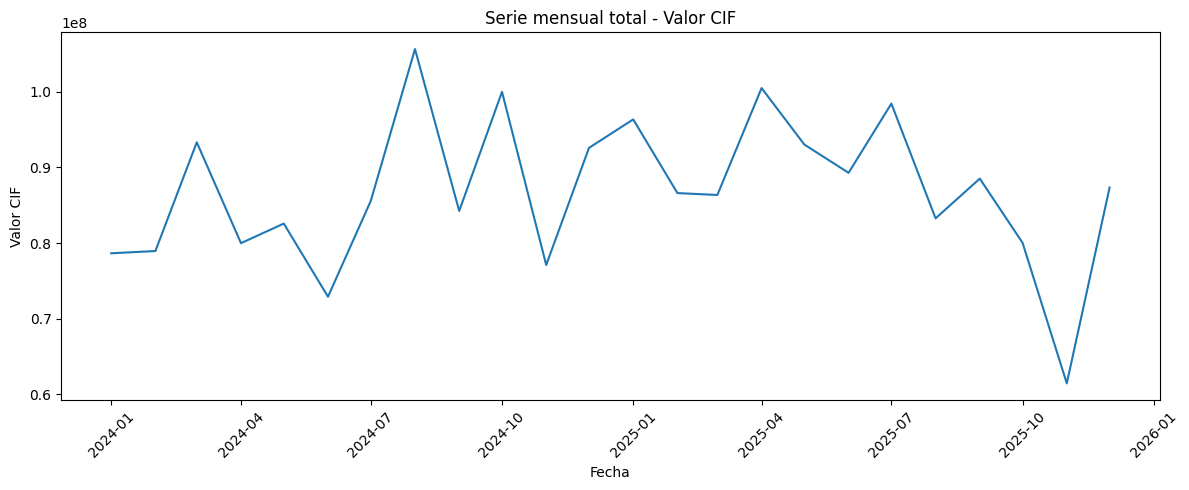

[OK] Gráfico guardado: C:\Users\roberto.sepulveda\OneDrive - udp.cl\Escritorio\Roberto\Magister 2025\MBD0010\Tarea_Final\Proyecto_Logistica_Cencosud\results\graphics\serie_mensual_peso_total.png


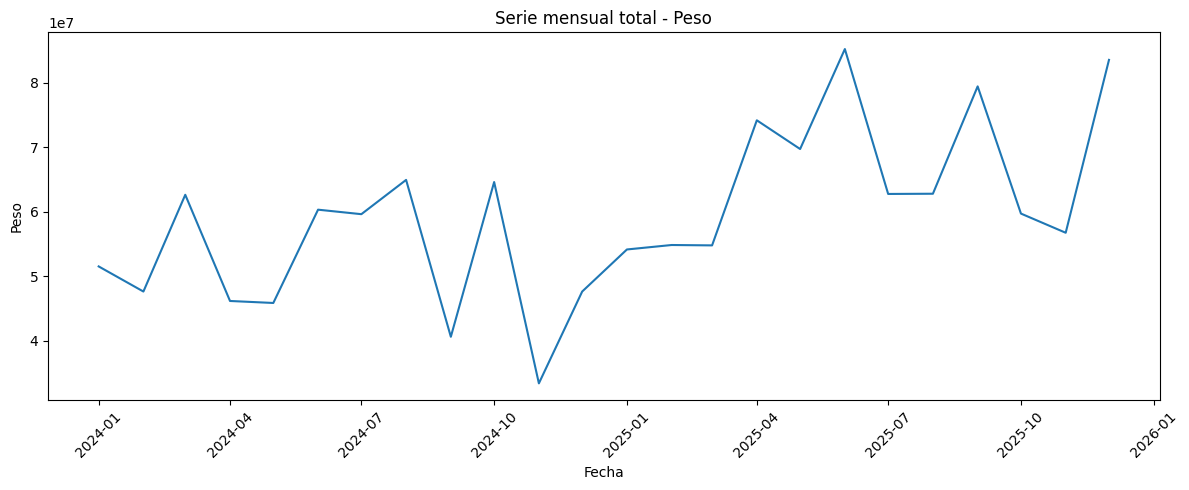

[OK] Gráfico guardado: C:\Users\roberto.sepulveda\OneDrive - udp.cl\Escritorio\Roberto\Magister 2025\MBD0010\Tarea_Final\Proyecto_Logistica_Cencosud\results\graphics\serie_mensual_cantidad_total.png


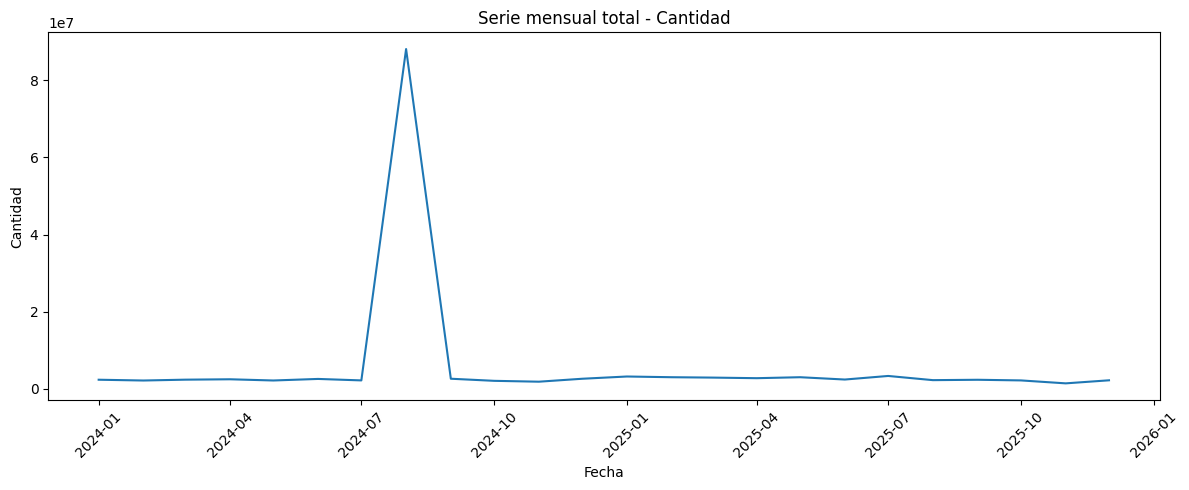

In [12]:
if "monthly_total" in globals():
    print("Resumen estadístico mensual total:")
    display(monthly_total.describe())

    plt.figure(figsize=(12, 5))
    plt.plot(monthly_total["fecha_mes"], monthly_total["valor_cif"])
    plt.title("Serie mensual total - Valor CIF")
    plt.xlabel("Fecha")
    plt.ylabel("Valor CIF")
    plt.xticks(rotation=45)
    plt.tight_layout()
    guardar_figura("serie_mensual_valor_cif_total.png")
    plt.show()

    plt.figure(figsize=(12, 5))
    plt.plot(monthly_total["fecha_mes"], monthly_total["peso"])
    plt.title("Serie mensual total - Peso")
    plt.xlabel("Fecha")
    plt.ylabel("Peso")
    plt.xticks(rotation=45)
    plt.tight_layout()
    guardar_figura("serie_mensual_peso_total.png")
    plt.show()

    plt.figure(figsize=(12, 5))
    plt.plot(monthly_total["fecha_mes"], monthly_total["cantidad"])
    plt.title("Serie mensual total - Cantidad")
    plt.xlabel("Fecha")
    plt.ylabel("Cantidad")
    plt.xticks(rotation=45)
    plt.tight_layout()
    guardar_figura("serie_mensual_cantidad_total.png")
    plt.show()
else:
    print("[WARNING] No existe monthly_total.")

## BLOQUE 13 — EDA por HS

[OK] Gráfico guardado: C:\Users\roberto.sepulveda\OneDrive - udp.cl\Escritorio\Roberto\Magister 2025\MBD0010\Tarea_Final\Proyecto_Logistica_Cencosud\results\graphics\serie_por_hs_valor_cif.png


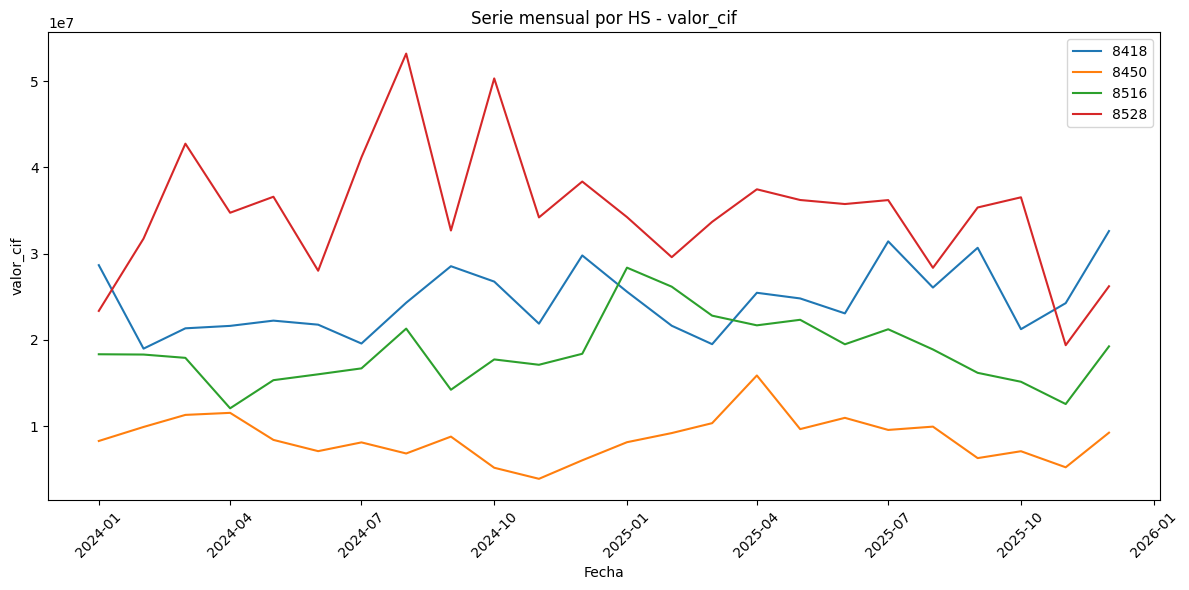

[OK] Gráfico guardado: C:\Users\roberto.sepulveda\OneDrive - udp.cl\Escritorio\Roberto\Magister 2025\MBD0010\Tarea_Final\Proyecto_Logistica_Cencosud\results\graphics\serie_por_hs_peso.png


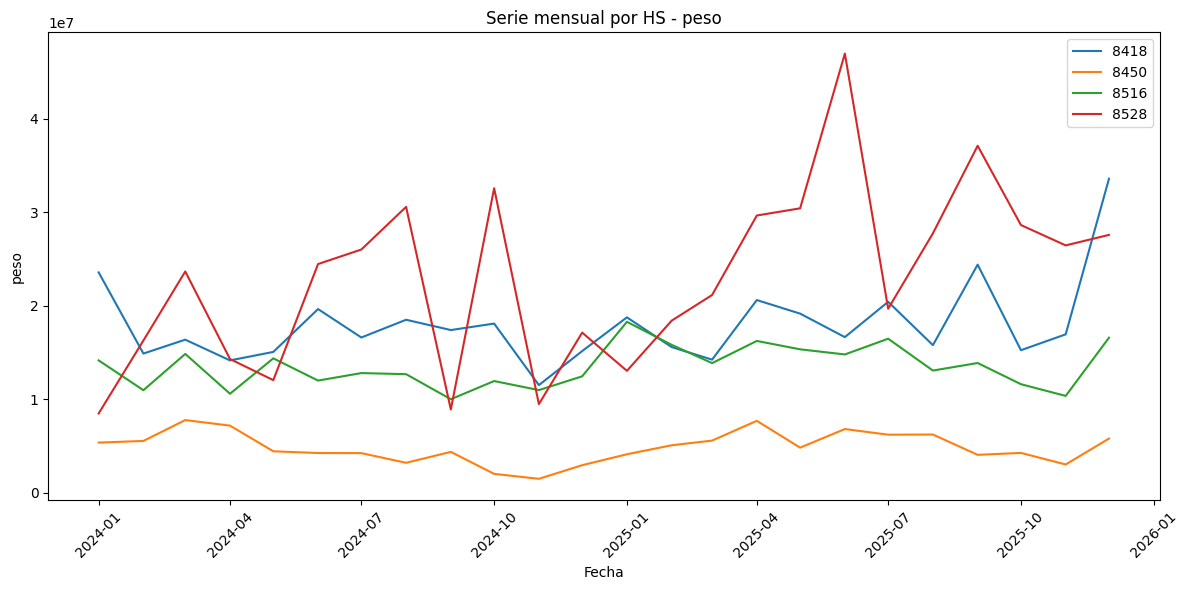

[OK] Gráfico guardado: C:\Users\roberto.sepulveda\OneDrive - udp.cl\Escritorio\Roberto\Magister 2025\MBD0010\Tarea_Final\Proyecto_Logistica_Cencosud\results\graphics\serie_por_hs_cantidad.png


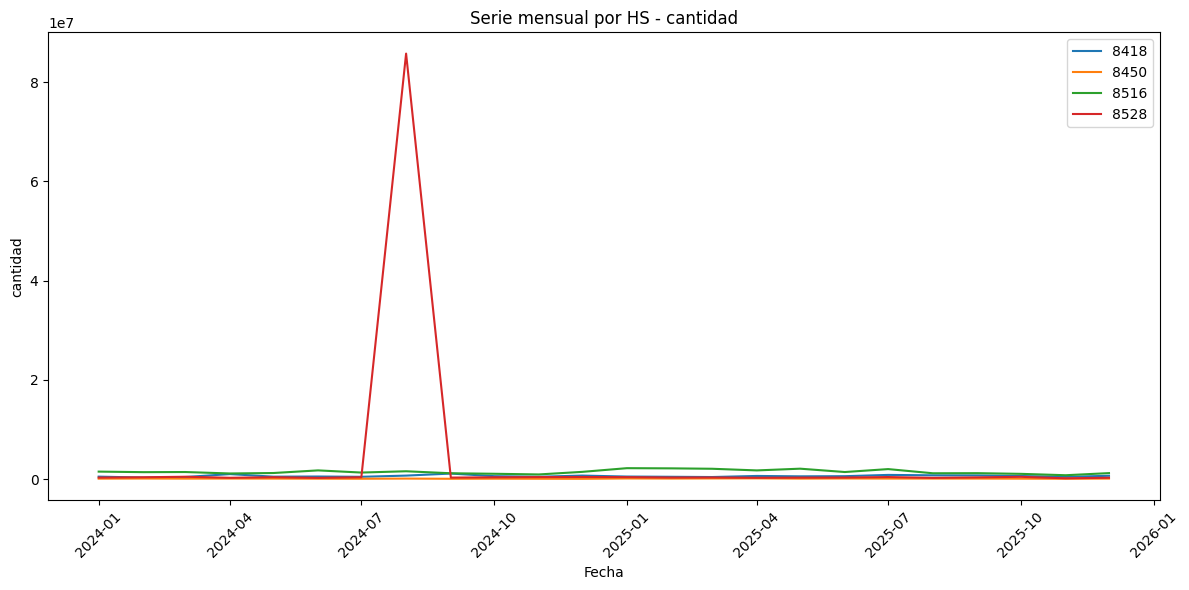

In [13]:
if "monthly_by_hs" in globals():
    for variable in VARIABLES_OBJETIVO:
        plt.figure(figsize=(12, 6))
        for hs in sorted(monthly_by_hs["hs4"].unique()):
            temp = monthly_by_hs[monthly_by_hs["hs4"] == hs]
            plt.plot(temp["fecha_mes"], temp[variable], label=hs)

        plt.title(f"Serie mensual por HS - {variable}")
        plt.xlabel("Fecha")
        plt.ylabel(variable)
        plt.legend()
        plt.xticks(rotation=45)
        plt.tight_layout()
        guardar_figura(f"serie_por_hs_{variable}.png")
        plt.show()
else:
    print("[WARNING] No existe monthly_by_hs.")

## BLOQUE 14 — Modelado: preparación de datos

In [14]:
resultados_metricas = []
resultados_predicciones = {}
resultados_forecast = {}

if "monthly_total" in globals():
    print("Iniciando modelado...")
else:
    print("[ERROR] No existe monthly_total; no se puede modelar.")

Iniciando modelado...


## BLOQUE 15 — Modelado por variable objetivo

In [15]:
if "monthly_total" in globals():
    for target_col in VARIABLES_OBJETIVO:
        print("=" * 80)
        print(f"VARIABLE OBJETIVO: {target_col}")
        print("=" * 80)

        df_feat = crear_features_temporales(monthly_total, target_col)

        # 1) ARIMA
        mets, pred_df, err = entrenar_y_evaluar_arima(monthly_total, target_col)
        if mets is not None:
            resultados_metricas.append({"variable": target_col, **mets})
            resultados_predicciones[f"{target_col}_ARIMA"] = pred_df
            forecast_df = forecast_arima(monthly_total, target_col)
            if forecast_df is not None:
                forecast_df["modelo"] = "ARIMA"
                forecast_df["variable"] = target_col
                resultados_forecast[f"{target_col}_ARIMA"] = forecast_df
            print("[OK] ARIMA evaluado.")
        else:
            print(f"[WARNING] ARIMA no disponible para {target_col}: {err}")

        # 2) Regresión Lineal
        mets, pred_df, err = entrenar_y_evaluar_supervisado(
            df_feat, target_col, "Regresión Lineal", LinearRegression()
        )
        if mets is not None:
            resultados_metricas.append({"variable": target_col, **mets})
            resultados_predicciones[f"{target_col}_RegresionLineal"] = pred_df
            forecast_df = forecast_supervisado(df_feat, target_col, LinearRegression())
            if forecast_df is not None:
                forecast_df["modelo"] = "Regresión Lineal"
                forecast_df["variable"] = target_col
                resultados_forecast[f"{target_col}_RegresionLineal"] = forecast_df
            print("[OK] Regresión Lineal evaluada.")
        else:
            print(f"[WARNING] Regresión Lineal no disponible para {target_col}: {err}")

        # 3) Random Forest
        mets, pred_df, err = entrenar_y_evaluar_supervisado(
            df_feat, target_col, "Random Forest",
            RandomForestRegressor(n_estimators=200, random_state=42, max_depth=6)
        )
        if mets is not None:
            resultados_metricas.append({"variable": target_col, **mets})
            resultados_predicciones[f"{target_col}_RandomForest"] = pred_df
            forecast_df = forecast_supervisado(
                df_feat, target_col,
                RandomForestRegressor(n_estimators=200, random_state=42, max_depth=6)
            )
            if forecast_df is not None:
                forecast_df["modelo"] = "Random Forest"
                forecast_df["variable"] = target_col
                resultados_forecast[f"{target_col}_RandomForest"] = forecast_df
            print("[OK] Random Forest evaluado.")
        else:
            print(f"[WARNING] Random Forest no disponible para {target_col}: {err}")

        # 4) XGBoost
        if xgboost_disponible:
            mets, pred_df, err = entrenar_y_evaluar_supervisado(
                df_feat, target_col, "XGBoost",
                XGBRegressor(
                    n_estimators=200,
                    learning_rate=0.05,
                    max_depth=4,
                    random_state=42
                )
            )
            if mets is not None:
                resultados_metricas.append({"variable": target_col, **mets})
                resultados_predicciones[f"{target_col}_XGBoost"] = pred_df
                forecast_df = forecast_supervisado(
                    df_feat, target_col,
                    XGBRegressor(
                        n_estimators=200,
                        learning_rate=0.05,
                        max_depth=4,
                        random_state=42
                    )
                )
                if forecast_df is not None:
                    forecast_df["modelo"] = "XGBoost"
                    forecast_df["variable"] = target_col
                    resultados_forecast[f"{target_col}_XGBoost"] = forecast_df
                print("[OK] XGBoost evaluado.")
            else:
                print(f"[WARNING] XGBoost no disponible para {target_col}: {err}")
        else:
            print("[INFO] XGBoost no instalado.")

        # 5) LightGBM
        if lightgbm_disponible:
            mets, pred_df, err = entrenar_y_evaluar_supervisado(
                df_feat, target_col, "LightGBM",
                LGBMRegressor(
                    n_estimators=200,
                    learning_rate=0.05,
                    max_depth=4,
                    random_state=42
                )
            )
            if mets is not None:
                resultados_metricas.append({"variable": target_col, **mets})
                resultados_predicciones[f"{target_col}_LightGBM"] = pred_df
                forecast_df = forecast_supervisado(
                    df_feat, target_col,
                    LGBMRegressor(
                        n_estimators=200,
                        learning_rate=0.05,
                        max_depth=4,
                        random_state=42
                    )
                )
                if forecast_df is not None:
                    forecast_df["modelo"] = "LightGBM"
                    forecast_df["variable"] = target_col
                    resultados_forecast[f"{target_col}_LightGBM"] = forecast_df
                print("[OK] LightGBM evaluado.")
            else:
                print(f"[WARNING] LightGBM no disponible para {target_col}: {err}")
        else:
            print("[INFO] LightGBM no instalado.")

VARIABLE OBJETIVO: valor_cif
[OK] ARIMA evaluado.
[OK] Regresión Lineal evaluada.
[OK] Random Forest evaluado.
[OK] XGBoost evaluado.
[LightGBM] [Warning] There are no meaningful features which satisfy the provided configuration. Decreasing Dataset parameters min_data_in_bin or min_data_in_leaf and re-constructing Dataset might resolve this warning.
[LightGBM] [Info] Total Bins 0
[LightGBM] [Info] Number of data points in the train set: 12, number of used features: 0
[LightGBM] [Info] Start training from score 91449145.333333
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there 

## BLOQUE 16 — Tabla comparativa de métricas

In [16]:
if len(resultados_metricas) > 0:
    metricas_df = pd.DataFrame(resultados_metricas)
    metricas_df = metricas_df.sort_values(["variable", "rmse", "mae"]).reset_index(drop=True)

    print("Métricas comparativas:")
    display(metricas_df)

    guardar_tabla(metricas_df, "metricas_comparativas_modelos.csv")
else:
    print("[WARNING] No se generaron métricas.")

Métricas comparativas:


,variable,mae,rmse,mape,r2,modelo
0,cantidad,3.876547e+06,3.911438e+06,186.156565,-47.798793,ARIMA
1,cantidad,7.438111e+06,7.459157e+06,351.982716,-176.466176,LightGBM
2,cantidad,1.301007e+07,1.381037e+07,637.764704,-607.340788,Regresión Lineal
3,cantidad,8.519121e+06,1.622530e+07,406.775354,-838.694714,Random Forest
4,cantidad,1.468014e+07,3.487267e+07,667.268975,-3877.882393,XGBoost
5,peso,1.008789e+07,1.289650e+07,13.662736,-0.609744,Random Forest
6,peso,9.482189e+06,1.347697e+07,12.372410,-0.757912,LightGBM
7,peso,1.438321e+07,1.722747e+07,23.720943,-1.872471,ARIMA
8,peso,1.627543e+07,1.887299e+07,26.605254,-2.447421,XGBoost
9,peso,1.715733e+07,1.956057e+07,24.631422,-2.703189,Regresión Lineal


[OK] Tabla guardada: C:\Users\roberto.sepulveda\OneDrive - udp.cl\Escritorio\Roberto\Magister 2025\MBD0010\Tarea_Final\Proyecto_Logistica_Cencosud\results\tables\metricas_comparativas_modelos.csv


## BLOQUE 17 — Mejor modelo por variable

In [17]:
if "metricas_df" in globals():
    mejores_modelos = (
        metricas_df.sort_values(["variable", "rmse", "mae"])
        .groupby("variable", as_index=False)
        .first()
    )

    print("Mejor modelo por variable:")
    display(mejores_modelos)

    guardar_tabla(mejores_modelos, "mejores_modelos_por_variable.csv")
else:
    print("[WARNING] No existe metricas_df.")

Mejor modelo por variable:


,variable,mae,rmse,mape,r2,modelo
0,cantidad,3.876547e+06,3.911438e+06,186.156565,-47.798793,ARIMA
1,peso,1.008789e+07,1.289650e+07,13.662736,-0.609744,Random Forest
2,valor_cif,9.043713e+06,1.272761e+07,12.578928,-0.276679,ARIMA


[OK] Tabla guardada: C:\Users\roberto.sepulveda\OneDrive - udp.cl\Escritorio\Roberto\Magister 2025\MBD0010\Tarea_Final\Proyecto_Logistica_Cencosud\results\tables\mejores_modelos_por_variable.csv


## BLOQUE 18 — Forecast a 6 meses del mejor modelo

In [18]:
forecast_final = []

if "mejores_modelos" in globals():
    for _, row in mejores_modelos.iterrows():
        variable = row["variable"]
        modelo = row["modelo"]

        key_map = {
            "ARIMA": f"{variable}_ARIMA",
            "Regresión Lineal": f"{variable}_RegresionLineal",
            "Random Forest": f"{variable}_RandomForest",
            "XGBoost": f"{variable}_XGBoost",
            "LightGBM": f"{variable}_LightGBM"
        }

        clave = key_map.get(modelo)

        if clave in resultados_forecast:
            temp = resultados_forecast[clave].copy()
            forecast_final.append(temp)

    if len(forecast_final) > 0:
        forecast_final_df = pd.concat(forecast_final, ignore_index=True)
        print("Forecast final a 6 meses:")
        display(forecast_final_df)

        guardar_tabla(forecast_final_df, "forecast_6_meses_mejores_modelos.csv")
    else:
        print("[WARNING] No se generó forecast final.")
else:
    print("[WARNING] No existe mejores_modelos.")

Forecast final a 6 meses:


,fecha_mes,forecast,modelo,variable
0,2026-01-01,4.896163e+06,ARIMA,cantidad
1,2026-02-01,4.822292e+06,ARIMA,cantidad
2,2026-03-01,4.824322e+06,ARIMA,cantidad
3,2026-04-01,4.824267e+06,ARIMA,cantidad
4,2026-05-01,4.824268e+06,ARIMA,cantidad
5,2026-06-01,4.824268e+06,ARIMA,cantidad
6,2026-01-01,7.038354e+07,Random Forest,peso
7,2026-02-01,6.838778e+07,Random Forest,peso
8,2026-03-01,7.137909e+07,Random Forest,peso
9,2026-04-01,6.873047e+07,Random Forest,peso


[OK] Tabla guardada: C:\Users\roberto.sepulveda\OneDrive - udp.cl\Escritorio\Roberto\Magister 2025\MBD0010\Tarea_Final\Proyecto_Logistica_Cencosud\results\tables\forecast_6_meses_mejores_modelos.csv


## BLOQUE 19 — Gráficos de validación

[OK] Gráfico guardado: C:\Users\roberto.sepulveda\OneDrive - udp.cl\Escritorio\Roberto\Magister 2025\MBD0010\Tarea_Final\Proyecto_Logistica_Cencosud\results\graphics\validacion_valor_cif_ARIMA.png


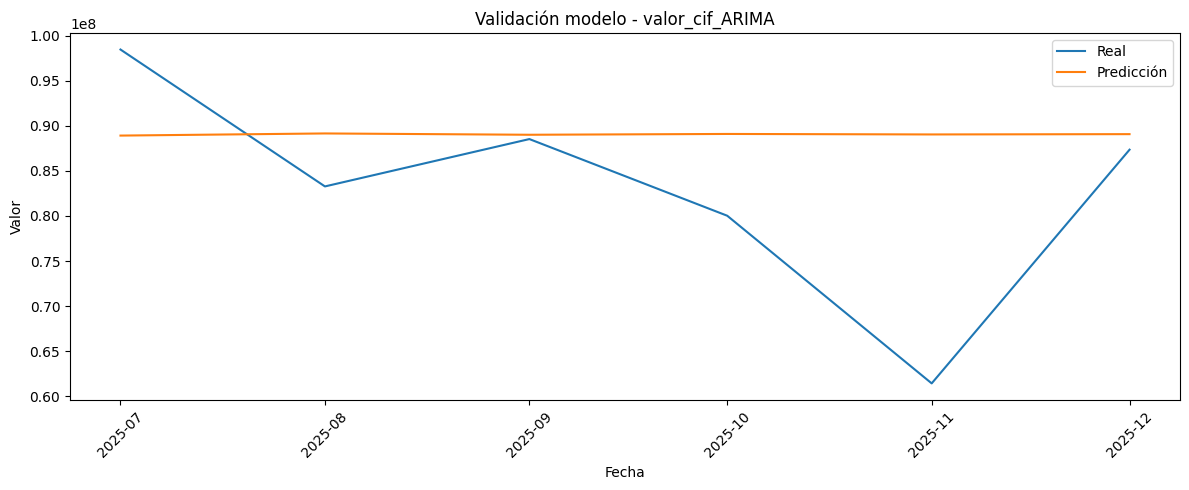

[OK] Gráfico guardado: C:\Users\roberto.sepulveda\OneDrive - udp.cl\Escritorio\Roberto\Magister 2025\MBD0010\Tarea_Final\Proyecto_Logistica_Cencosud\results\graphics\validacion_valor_cif_RegresionLineal.png


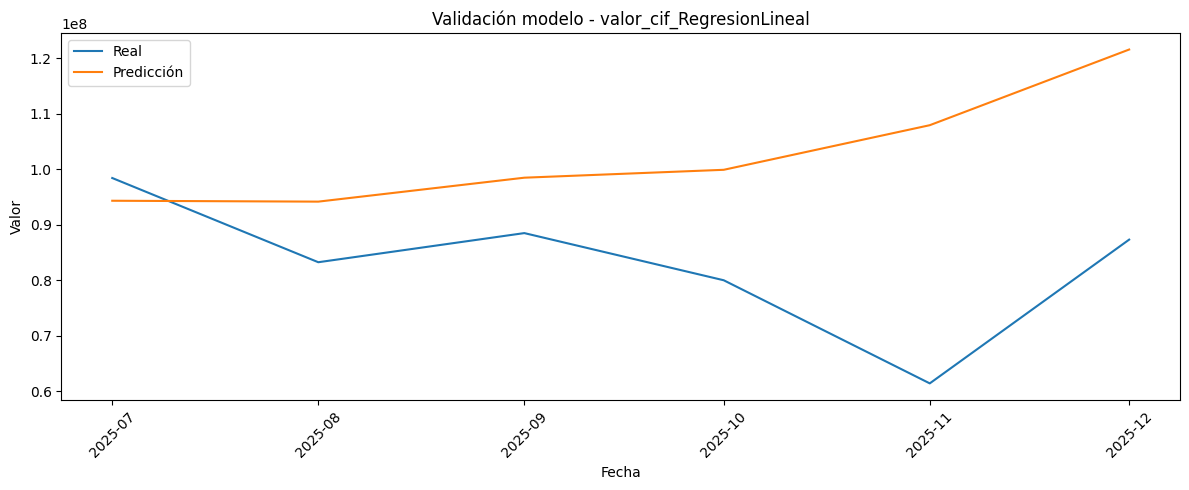

[OK] Gráfico guardado: C:\Users\roberto.sepulveda\OneDrive - udp.cl\Escritorio\Roberto\Magister 2025\MBD0010\Tarea_Final\Proyecto_Logistica_Cencosud\results\graphics\validacion_valor_cif_RandomForest.png


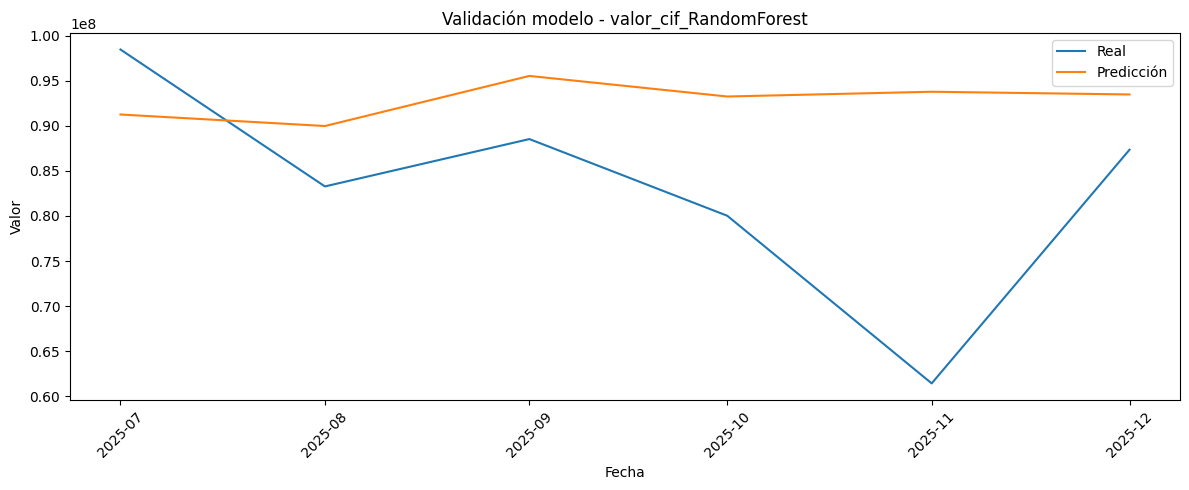

[OK] Gráfico guardado: C:\Users\roberto.sepulveda\OneDrive - udp.cl\Escritorio\Roberto\Magister 2025\MBD0010\Tarea_Final\Proyecto_Logistica_Cencosud\results\graphics\validacion_valor_cif_XGBoost.png


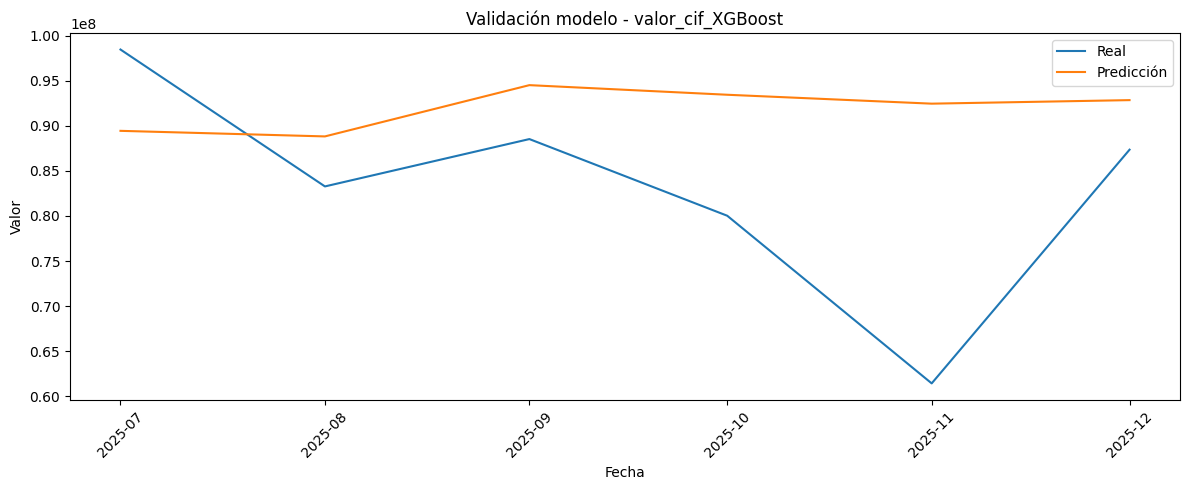

[OK] Gráfico guardado: C:\Users\roberto.sepulveda\OneDrive - udp.cl\Escritorio\Roberto\Magister 2025\MBD0010\Tarea_Final\Proyecto_Logistica_Cencosud\results\graphics\validacion_valor_cif_LightGBM.png


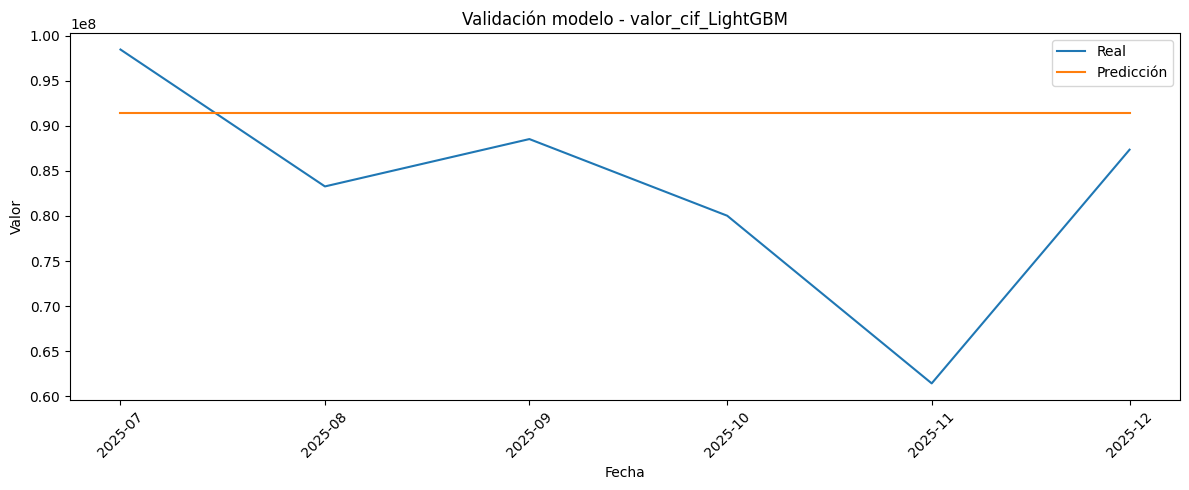

[OK] Gráfico guardado: C:\Users\roberto.sepulveda\OneDrive - udp.cl\Escritorio\Roberto\Magister 2025\MBD0010\Tarea_Final\Proyecto_Logistica_Cencosud\results\graphics\validacion_peso_ARIMA.png


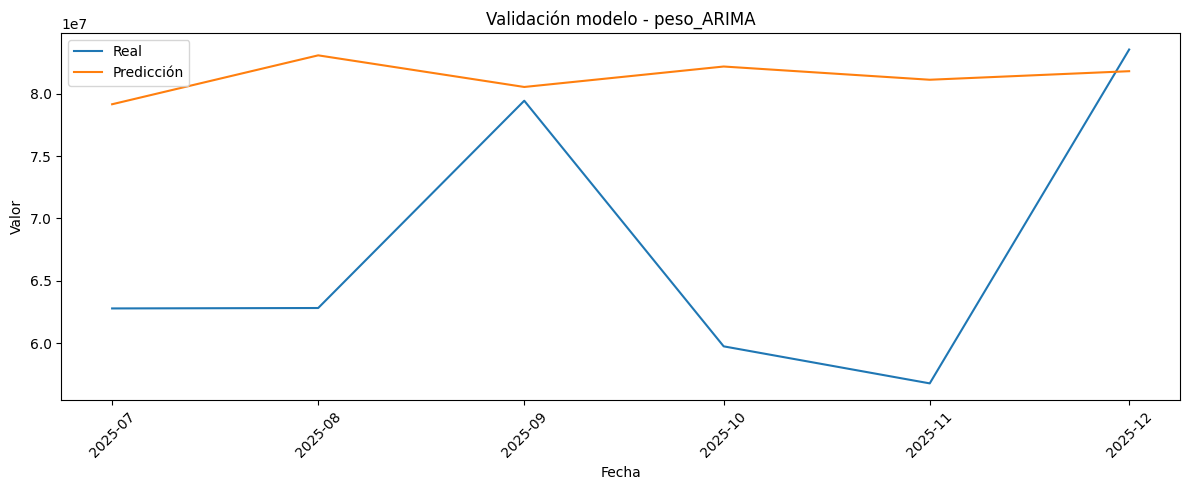

[OK] Gráfico guardado: C:\Users\roberto.sepulveda\OneDrive - udp.cl\Escritorio\Roberto\Magister 2025\MBD0010\Tarea_Final\Proyecto_Logistica_Cencosud\results\graphics\validacion_peso_RegresionLineal.png


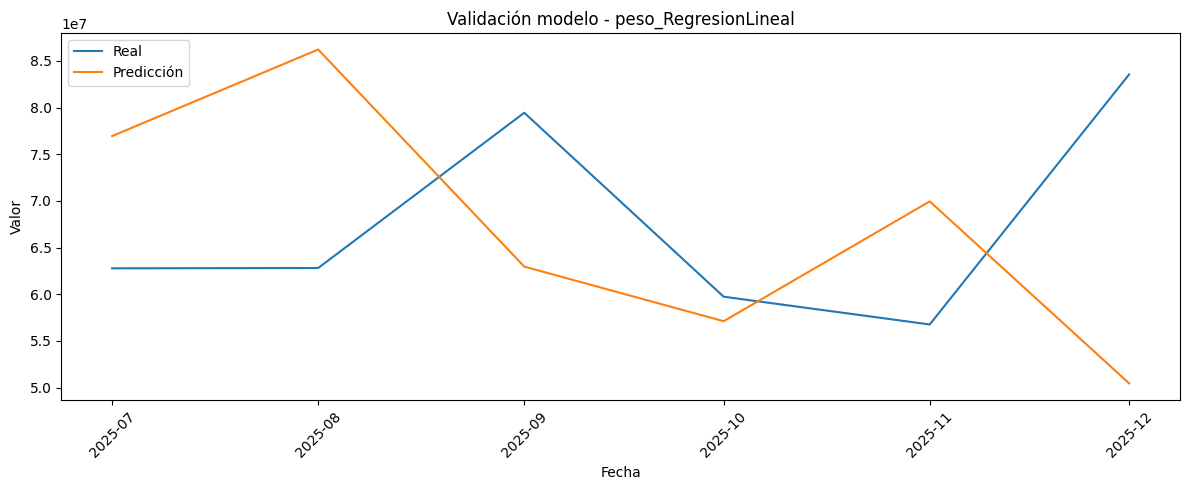

[OK] Gráfico guardado: C:\Users\roberto.sepulveda\OneDrive - udp.cl\Escritorio\Roberto\Magister 2025\MBD0010\Tarea_Final\Proyecto_Logistica_Cencosud\results\graphics\validacion_peso_RandomForest.png


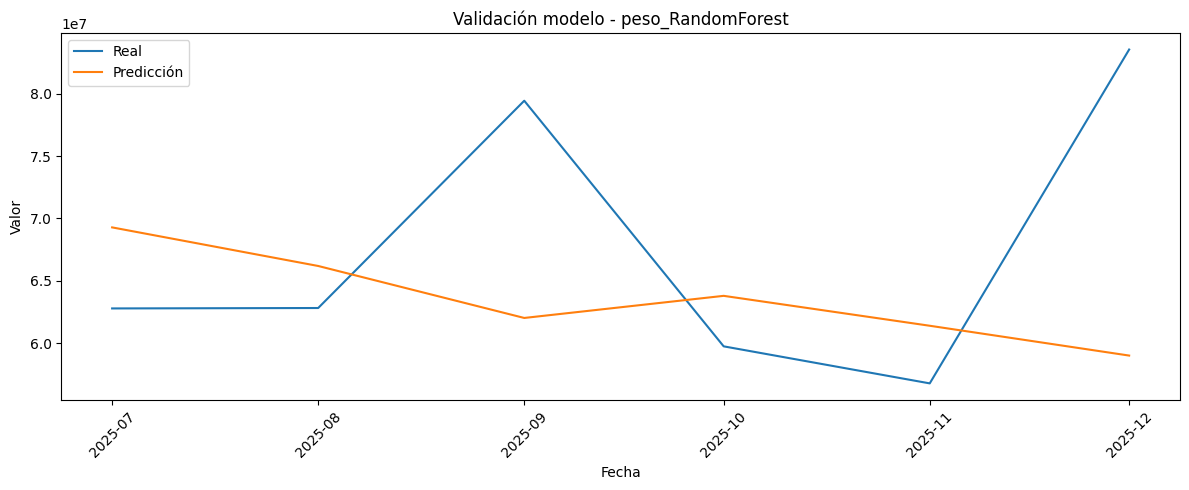

[OK] Gráfico guardado: C:\Users\roberto.sepulveda\OneDrive - udp.cl\Escritorio\Roberto\Magister 2025\MBD0010\Tarea_Final\Proyecto_Logistica_Cencosud\results\graphics\validacion_peso_XGBoost.png


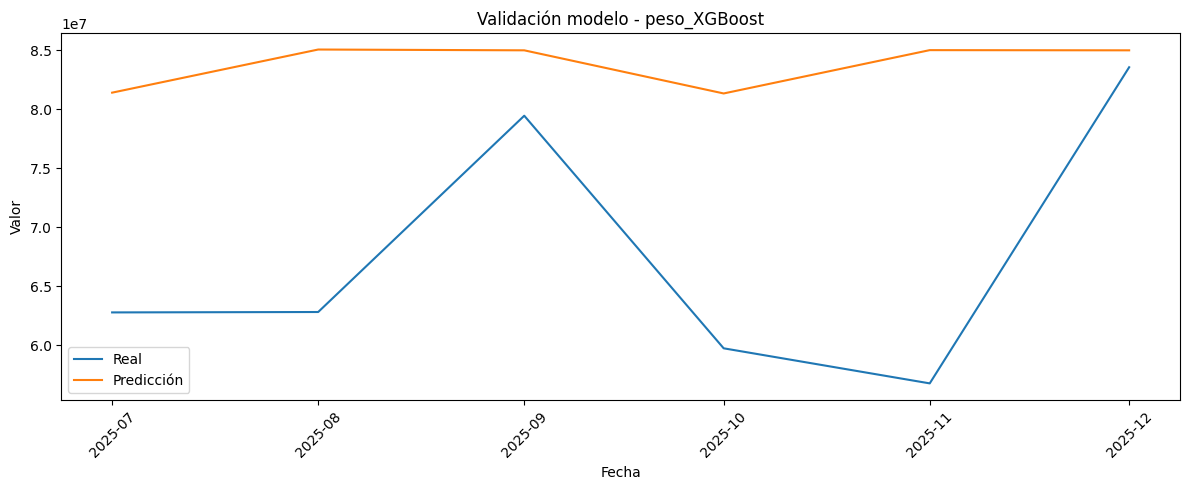

[OK] Gráfico guardado: C:\Users\roberto.sepulveda\OneDrive - udp.cl\Escritorio\Roberto\Magister 2025\MBD0010\Tarea_Final\Proyecto_Logistica_Cencosud\results\graphics\validacion_peso_LightGBM.png


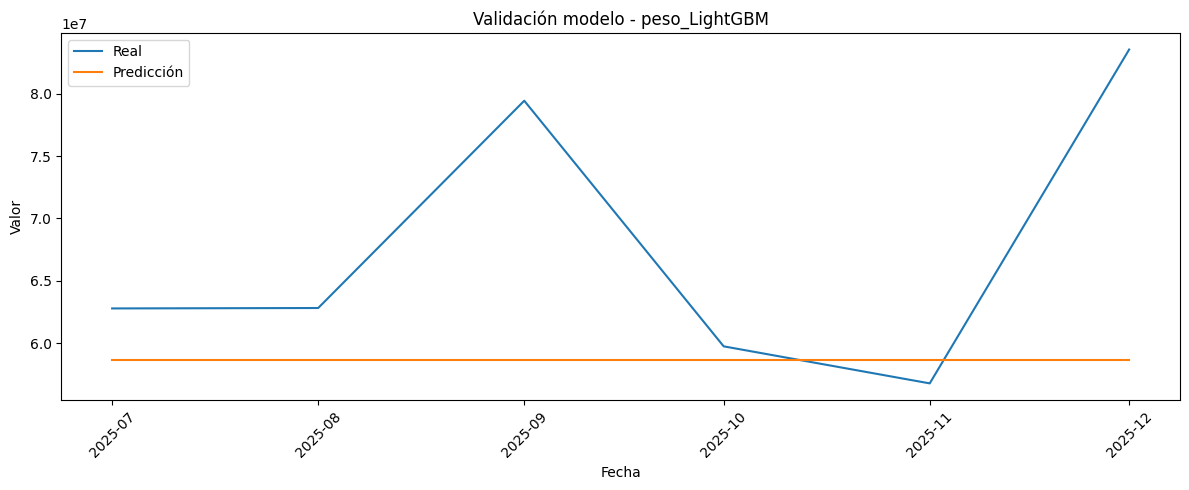

[OK] Gráfico guardado: C:\Users\roberto.sepulveda\OneDrive - udp.cl\Escritorio\Roberto\Magister 2025\MBD0010\Tarea_Final\Proyecto_Logistica_Cencosud\results\graphics\validacion_cantidad_ARIMA.png


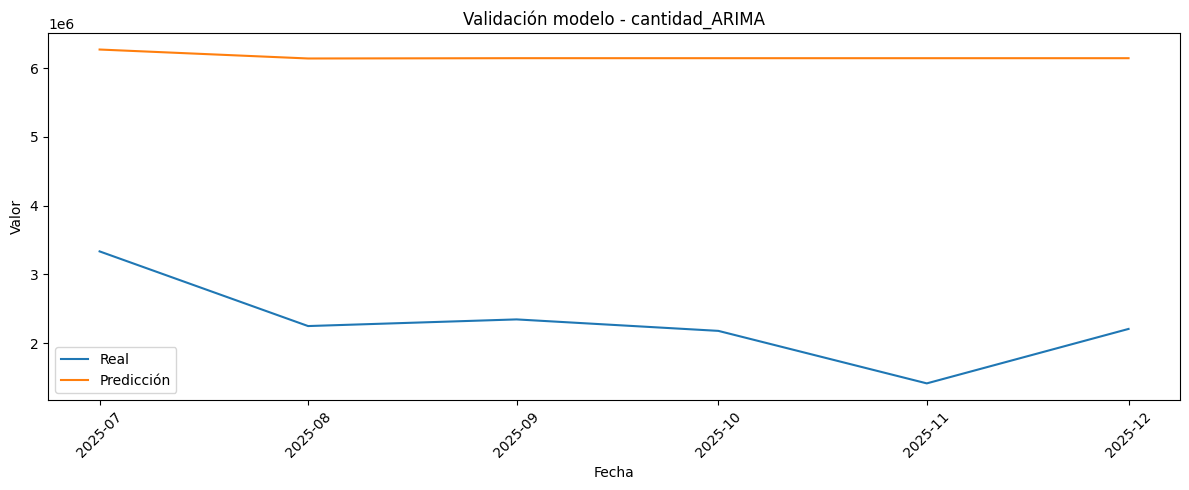

[OK] Gráfico guardado: C:\Users\roberto.sepulveda\OneDrive - udp.cl\Escritorio\Roberto\Magister 2025\MBD0010\Tarea_Final\Proyecto_Logistica_Cencosud\results\graphics\validacion_cantidad_RegresionLineal.png


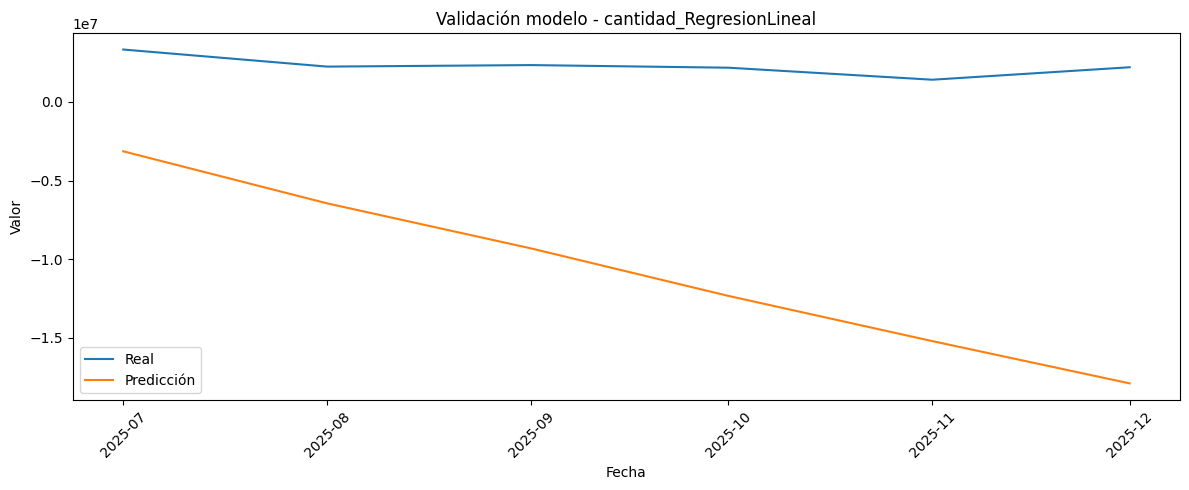

[OK] Gráfico guardado: C:\Users\roberto.sepulveda\OneDrive - udp.cl\Escritorio\Roberto\Magister 2025\MBD0010\Tarea_Final\Proyecto_Logistica_Cencosud\results\graphics\validacion_cantidad_RandomForest.png


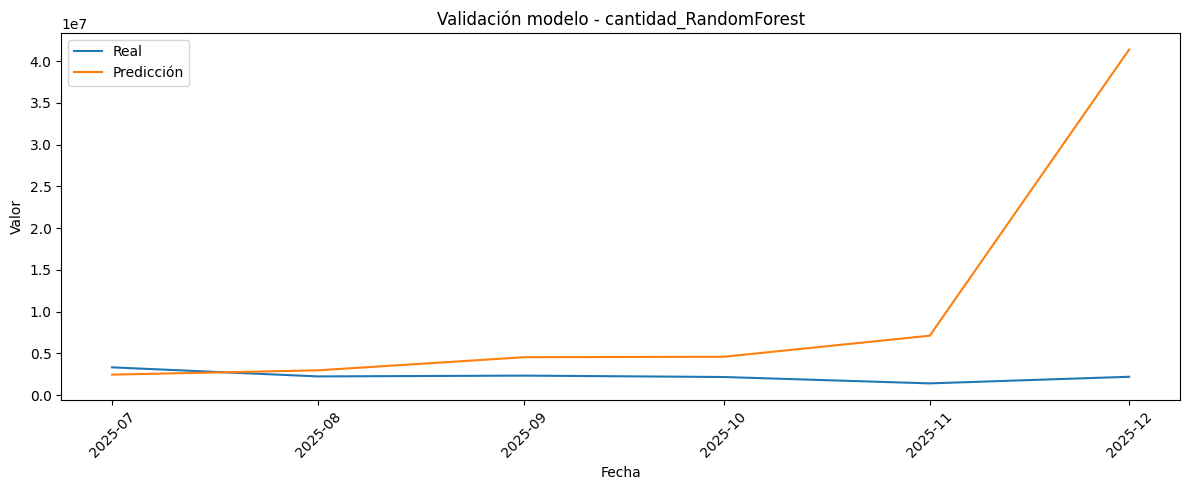

[OK] Gráfico guardado: C:\Users\roberto.sepulveda\OneDrive - udp.cl\Escritorio\Roberto\Magister 2025\MBD0010\Tarea_Final\Proyecto_Logistica_Cencosud\results\graphics\validacion_cantidad_XGBoost.png


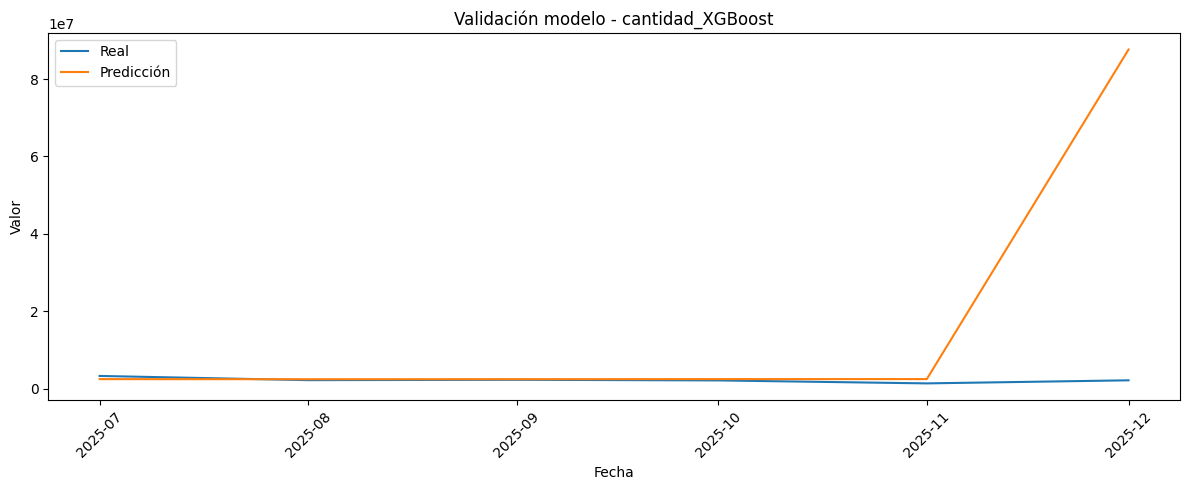

[OK] Gráfico guardado: C:\Users\roberto.sepulveda\OneDrive - udp.cl\Escritorio\Roberto\Magister 2025\MBD0010\Tarea_Final\Proyecto_Logistica_Cencosud\results\graphics\validacion_cantidad_LightGBM.png


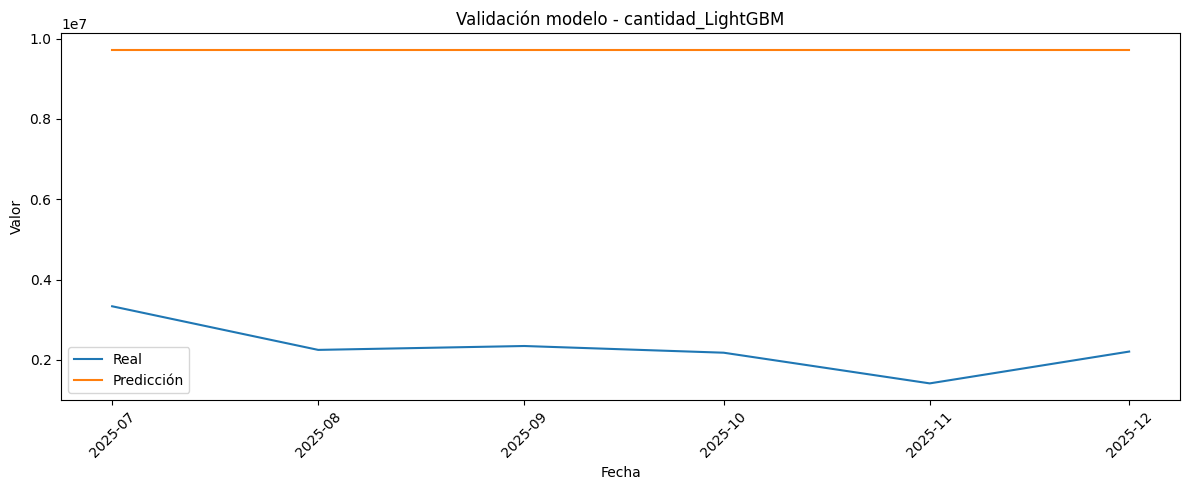

In [19]:
if len(resultados_predicciones) > 0:
    for nombre, pred_df in resultados_predicciones.items():
        plt.figure(figsize=(12, 5))
        plt.plot(pred_df["fecha_mes"], pred_df["y_real"], label="Real")
        plt.plot(pred_df["fecha_mes"], pred_df["y_pred"], label="Predicción")
        plt.title(f"Validación modelo - {nombre}")
        plt.xlabel("Fecha")
        plt.ylabel("Valor")
        plt.legend()
        plt.xticks(rotation=45)
        plt.tight_layout()
        guardar_figura(f"validacion_{nombre}.png")
        plt.show()
else:
    print("[WARNING] No existen predicciones para graficar.")

## BLOQUE 20 — Gráficos del forecast final

[OK] Gráfico guardado: C:\Users\roberto.sepulveda\OneDrive - udp.cl\Escritorio\Roberto\Magister 2025\MBD0010\Tarea_Final\Proyecto_Logistica_Cencosud\results\graphics\forecast_cantidad.png


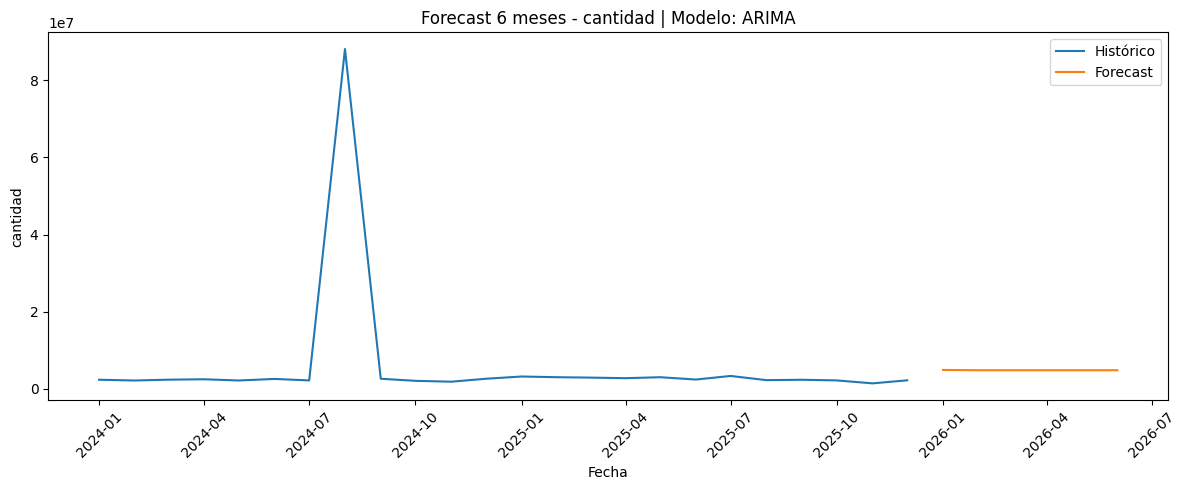

[OK] Gráfico guardado: C:\Users\roberto.sepulveda\OneDrive - udp.cl\Escritorio\Roberto\Magister 2025\MBD0010\Tarea_Final\Proyecto_Logistica_Cencosud\results\graphics\forecast_peso.png


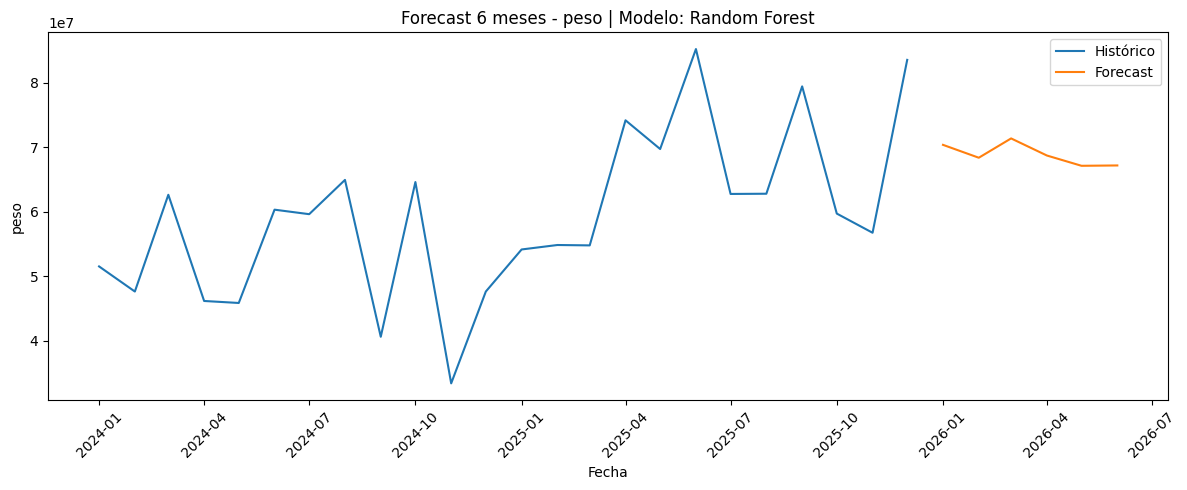

[OK] Gráfico guardado: C:\Users\roberto.sepulveda\OneDrive - udp.cl\Escritorio\Roberto\Magister 2025\MBD0010\Tarea_Final\Proyecto_Logistica_Cencosud\results\graphics\forecast_valor_cif.png


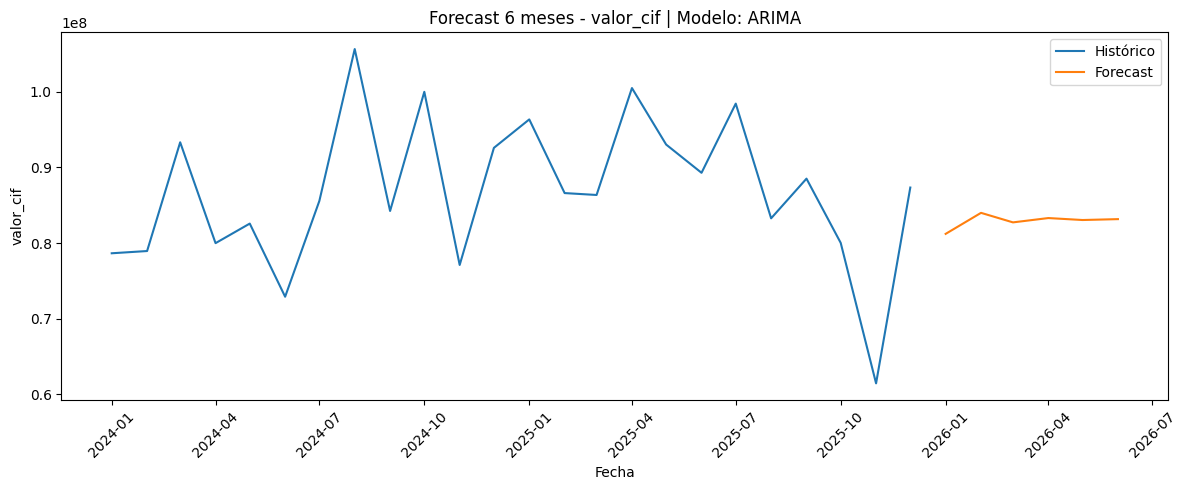

In [20]:
if "forecast_final_df" in globals() and "monthly_total" in globals():
    for variable in forecast_final_df["variable"].unique():
        plt.figure(figsize=(12, 5))

        historico = monthly_total[["fecha_mes", variable]].copy()
        futuro = forecast_final_df[forecast_final_df["variable"] == variable].copy()

        plt.plot(historico["fecha_mes"], historico[variable], label="Histórico")
        plt.plot(futuro["fecha_mes"], futuro["forecast"], label="Forecast")

        modelo_nombre = futuro["modelo"].iloc[0] if len(futuro) > 0 else "N/D"

        plt.title(f"Forecast 6 meses - {variable} | Modelo: {modelo_nombre}")
        plt.xlabel("Fecha")
        plt.ylabel(variable)
        plt.legend()
        plt.xticks(rotation=45)
        plt.tight_layout()
        guardar_figura(f"forecast_{variable}.png")
        plt.show()
else:
    print("[WARNING] No existe forecast_final_df.")

## BLOQUE 21 — Resumen ejecutivo automático

In [21]:
resumen_ejecutivo = []

resumen_ejecutivo.append("RESUMEN EJECUTIVO")
resumen_ejecutivo.append("=" * 80)
resumen_ejecutivo.append("Objetivo: estimar el comportamiento futuro de las importaciones de electrodomésticos en Chile para apoyar la planificación logística y de abastecimiento de Cencosud.")
resumen_ejecutivo.append("Variables analizadas: valor_cif, peso y cantidad.")
resumen_ejecutivo.append(f"Códigos HS considerados: {', '.join(HS_CODES_OBJETIVO)}.")
resumen_ejecutivo.append(f"Horizonte de predicción: {HORIZONTE_MESES} meses.")
resumen_ejecutivo.append("")

if "monthly_total" in globals():
    resumen_ejecutivo.append(f"Se construyó una serie mensual consolidada con {monthly_total.shape[0]} meses observados.")
else:
    resumen_ejecutivo.append("No fue posible construir la serie mensual consolidada.")

if "monthly_by_hs" in globals():
    resumen_ejecutivo.append(f"Se construyó una serie mensual por HS con {monthly_by_hs.shape[0]} registros.")
else:
    resumen_ejecutivo.append("No fue posible construir la serie mensual por HS.")

if "mejores_modelos" in globals():
    resumen_ejecutivo.append("")
    resumen_ejecutivo.append("Mejor modelo por variable:")
    for _, row in mejores_modelos.iterrows():
        resumen_ejecutivo.append(
            f"- {row['variable']}: {row['modelo']} | RMSE={row['rmse']:.2f} | MAE={row['mae']:.2f} | MAPE={row['mape']:.2f}%"
        )

if "forecast_final_df" in globals():
    resumen_ejecutivo.append("")
    resumen_ejecutivo.append("Forecast a 6 meses:")
    for variable in forecast_final_df["variable"].unique():
        temp = forecast_final_df[forecast_final_df["variable"] == variable].copy()
        modelo = temp["modelo"].iloc[0]
        resumen_ejecutivo.append(f"- Variable: {variable} | Modelo seleccionado: {modelo}")
        for _, r in temp.iterrows():
            resumen_ejecutivo.append(f"  {r['fecha_mes'].strftime('%Y-%m')}: {r['forecast']:.2f}")

texto_resumen = "\n".join(resumen_ejecutivo)
print(texto_resumen)

with open(RESULTS_DIR / "resumen_ejecutivo.txt", "w", encoding="utf-8") as f:
    f.write(texto_resumen)

print(f"\n[OK] Resumen ejecutivo guardado en: {RESULTS_DIR / 'resumen_ejecutivo.txt'}")

RESUMEN EJECUTIVO
Objetivo: estimar el comportamiento futuro de las importaciones de electrodomésticos en Chile para apoyar la planificación logística y de abastecimiento de Cencosud.
Variables analizadas: valor_cif, peso y cantidad.
Códigos HS considerados: 8418, 8450, 8516, 8528.
Horizonte de predicción: 6 meses.

Se construyó una serie mensual consolidada con 24 meses observados.
Se construyó una serie mensual por HS con 96 registros.

Mejor modelo por variable:
- cantidad: ARIMA | RMSE=3911438.14 | MAE=3876546.87 | MAPE=186.16%
- peso: Random Forest | RMSE=12896501.30 | MAE=10087892.93 | MAPE=13.66%
- valor_cif: ARIMA | RMSE=12727613.45 | MAE=9043712.97 | MAPE=12.58%

Forecast a 6 meses:
- Variable: cantidad | Modelo seleccionado: ARIMA
  2026-01: 4896162.87
  2026-02: 4822292.07
  2026-03: 4824322.32
  2026-04: 4824266.52
  2026-05: 4824268.06
  2026-06: 4824268.02
- Variable: peso | Modelo seleccionado: Random Forest
  2026-01: 70383539.17
  2026-02: 68387781.68
  2026-03: 713790

## BLOQUE 22 — Validación final de entregables

In [22]:
print("Validación final de entregables")

entregables = [
    RESULTS_DIR / "resumen_ejecutivo.txt",
    TABLES_DIR / "dataset_final_modelado.csv",
    TABLES_DIR / "dataset_mensual_total.csv",
    TABLES_DIR / "dataset_mensual_por_hs.csv",
    TABLES_DIR / "metricas_comparativas_modelos.csv",
    TABLES_DIR / "mejores_modelos_por_variable.csv",
    TABLES_DIR / "forecast_6_meses_mejores_modelos.csv"
]

for ruta in entregables:
    print(f"{ruta.name}: {'OK' if ruta.exists() else 'NO GENERADO'}")

Validación final de entregables
resumen_ejecutivo.txt: OK
dataset_final_modelado.csv: OK
dataset_mensual_total.csv: OK
dataset_mensual_por_hs.csv: OK
metricas_comparativas_modelos.csv: OK
mejores_modelos_por_variable.csv: OK
forecast_6_meses_mejores_modelos.csv: OK
